# GARCH Volatility Modeling & VaR/CVaR Backtesting: VCB (Vietcombank)

**Data:** VCB daily closing prices, 2023-03-31 to 2026-03-31 (part of the same 40-stock VN
dataset used in the [Portfolio Optimization project](../../Portfolio-Optimization)).

**Motivation:** A simple exploratory pass on VCB's daily log returns shows strong evidence
against normality (heavy tails, negative skew) and significant volatility clustering
(ARCH effects). This notebook picks up from there and builds the natural next step: a
GARCH(1,1) model with Student-t errors to capture time-varying volatility, then uses it to
forecast **Value-at-Risk (VaR)** and **Conditional VaR / Expected Shortfall (CVaR)**, and
finally checks whether those risk forecasts are actually well-calibrated with a proper
walk-forward backtest.

**Sections:**
1. Data & descriptive statistics
2. Testing the normality and volatility-clustering assumptions
3. GARCH(1,1) model fitting
4. Walk-forward VaR / CVaR forecasting
5. Backtesting the VaR forecasts (Kupiec test)
6. Results & discussion
7. Limitations


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.stats as stats
from arch import arch_model
from statsmodels.stats.diagnostic import het_arch

pd.set_option("display.precision", 4)
plt.rcParams["figure.dpi"] = 110


## 1. Data & descriptive statistics

Log returns are used (standard for volatility modeling) and scaled to percent, which is the
convention the `arch` package expects for numerically stable optimization.


In [2]:
df = pd.read_csv("../data/vn_stock_prices_raw.csv", parse_dates=["Date"])
df = df.sort_values("Date").set_index("Date")

vcb_price = df["VCB"]
log_ret = (np.log(vcb_price / vcb_price.shift(1)).dropna()) * 100  # in percent

print(f"n = {len(log_ret)} trading days "
      f"({log_ret.index.min().date()} -> {log_ret.index.max().date()})")
print(f"Mean: {log_ret.mean():.4f}%   Std Dev: {log_ret.std():.4f}%")
print(f"Skewness: {log_ret.skew():.4f}   Kurtosis (excess): {log_ret.kurtosis():.4f}")


n = 746 trading days (2023-04-03 -> 2026-03-31)
Mean: -0.0059%   Std Dev: 1.5007%
Skewness: -0.5869   Kurtosis (excess): 13.1873


Excess kurtosis well above 0 (a normal distribution has excess kurtosis = 0) and negative
skew are the first hints that daily VCB returns are not normally distributed -- large moves,
especially large *down* moves, happen more often than a normal distribution would predict.


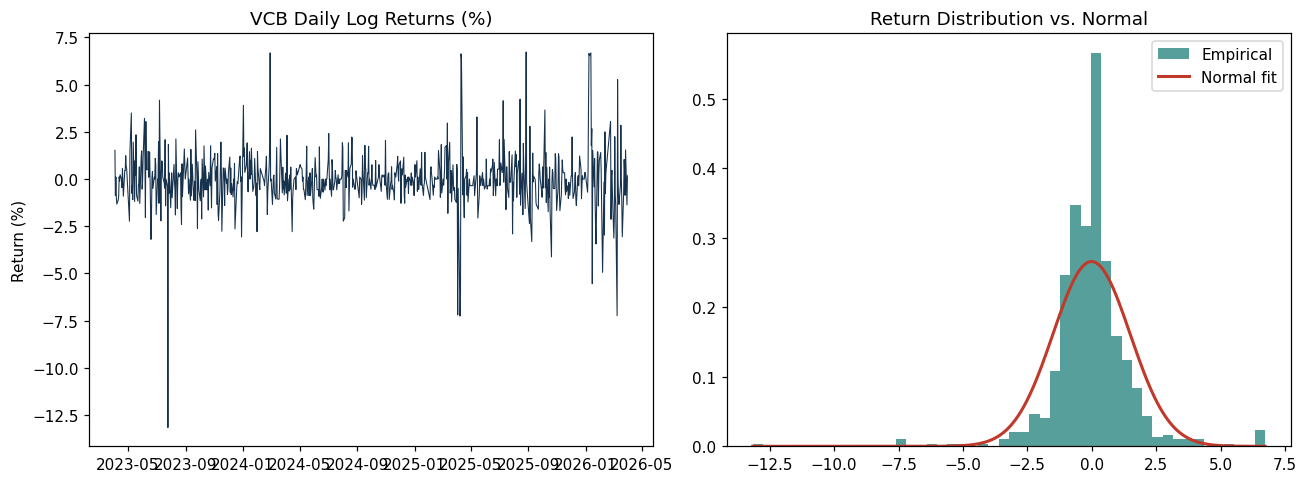

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
axes[0].plot(log_ret.index, log_ret.values, linewidth=0.7, color="#17324D")
axes[0].set_title("VCB Daily Log Returns (%)")
axes[0].set_ylabel("Return (%)")

axes[1].hist(log_ret, bins=50, density=True, color="#0E7770", alpha=0.7, label="Empirical")
x = np.linspace(log_ret.min(), log_ret.max(), 200)
axes[1].plot(x, stats.norm.pdf(x, log_ret.mean(), log_ret.std()), color="#C0392B",
             linewidth=2, label="Normal fit")
axes[1].set_title("Return Distribution vs. Normal")
axes[1].legend()
plt.tight_layout(); plt.show()


## 2. Testing the normality and volatility-clustering assumptions

Two formal tests justify moving beyond a constant-volatility, normal-returns model:

- **Jarque-Bera test** -- tests whether skewness and kurtosis match a normal distribution.
  $$JB = \frac{n}{6}\left(S^2 + \frac{(K-3)^2}{4}\right)$$
- **ARCH-LM test** -- tests whether squared returns are autocorrelated (i.e. whether large
  moves cluster together in time, which a constant-variance model cannot capture).


In [4]:
jb_stat, jb_p = stats.jarque_bera(log_ret)
print(f"Jarque-Bera: statistic={jb_stat:.2f}, p-value={jb_p:.6f}")
print("-> Reject normality" if jb_p < 0.05 else "-> Cannot reject normality")

lm_stat, lm_p, _, _ = het_arch(log_ret, nlags=5)
print(f"\nARCH-LM (5 lags): statistic={lm_stat:.2f}, p-value={lm_p:.6f}")
print("-> Significant volatility clustering (ARCH effects present)" if lm_p < 0.05
      else "-> No significant ARCH effects")


Jarque-Bera: statistic=5369.54, p-value=0.000000
-> Reject normality

ARCH-LM (5 lags): statistic=39.00, p-value=0.000000
-> Significant volatility clustering (ARCH effects present)


/usr/local/lib/python3.12/dist-packages/statsmodels/stats/diagnostic.py:997: FutureWarning: acorr_lm currently returns a plain tuple whose length depends on the store argument. In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning an LMTestResult NamedTuple. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.
  return acorr_lm(


Both tests reject their null hypotheses decisively. Returns are **not normal** (fat tails,
negative skew) and **volatility clusters** in time (large moves are followed by more large
moves). This is exactly the situation GARCH models were designed for.


## 3. GARCH(1,1) model fitting

A GARCH(1,1) model lets today's variance depend on yesterday's squared shock and yesterday's
variance:

$$\sigma_t^2 = \omega + \alpha \, \epsilon_{t-1}^2 + \beta \, \sigma_{t-1}^2$$

Given the heavy tails found above, innovations are modeled with a **Student-t distribution**
rather than a normal one -- letting the model itself decide how fat the tails should be
(via the estimated degrees-of-freedom parameter $\nu$), rather than force-fitting a normal
shape onto data that has already rejected it.


In [5]:
model = arch_model(log_ret, vol="Garch", p=1, q=1, dist="t")
res = model.fit(disp="off")
print(res.summary())


                        Constant Mean - GARCH Model Results                         
Dep. Variable:                          VCB   R-squared:                       0.000
Mean Model:                   Constant Mean   Adj. R-squared:                  0.000
Vol Model:                            GARCH   Log-Likelihood:               -1169.58
Distribution:      Standardized Student's t   AIC:                           2349.16
Method:                  Maximum Likelihood   BIC:                           2372.24
                                              No. Observations:                  746
Date:                      Sun, Aug 30 2026   Df Residuals:                      745
Time:                              13:10:11   Df Model:                            1
                                Mean Model                                
                 coef    std err          t      P>|t|    95.0% Conf. Int.
--------------------------------------------------------------------------
mu        

**Reading the output:**
- $\alpha + \beta \approx 0.87$ -- volatility shocks are highly persistent (a spike in
  volatility decays slowly), typical for equity returns.
- $\nu \approx 3.1$ -- a very low degrees-of-freedom estimate, confirming (independently of
  the Jarque-Bera test above) that VCB's return distribution has substantially fatter tails
  than a normal distribution. Extreme moves are far from rare here.


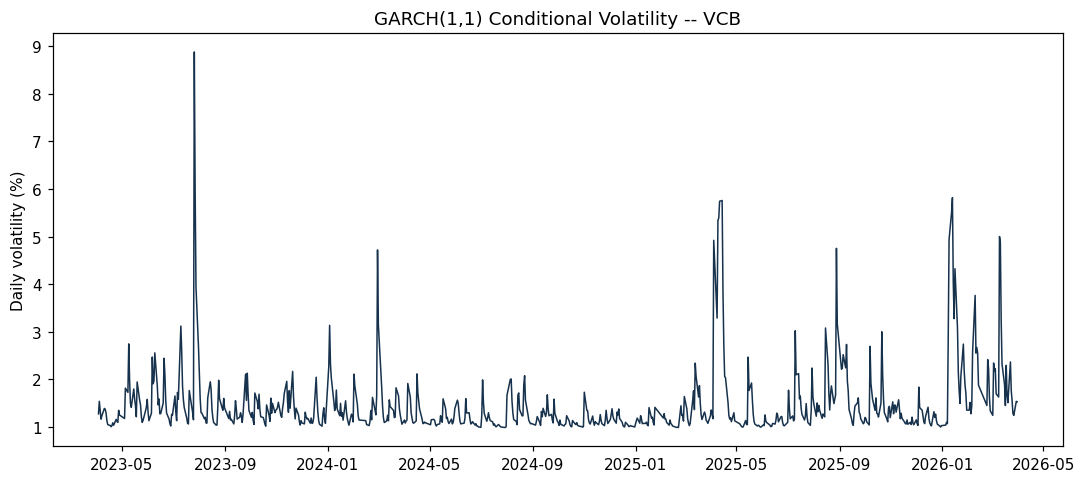

In [6]:
fig, ax = plt.subplots(figsize=(10, 4.5))
ax.plot(log_ret.index, res.conditional_volatility, color="#17324D", linewidth=1)
ax.set_title("GARCH(1,1) Conditional Volatility -- VCB")
ax.set_ylabel("Daily volatility (%)")
plt.tight_layout(); plt.show()


## 4. Walk-forward VaR / CVaR forecasting

At each point in time, using only the trailing 500 trading days (refitting the GARCH model
every 20 days to keep computation reasonable), forecast tomorrow's volatility and derive:

- **VaR** at the $\alpha$ level: the return threshold such that $P(R_{t+1} < VaR_\alpha) = \alpha$
- **CVaR (Expected Shortfall)**: the *expected* return, given that it falls below the VaR
  threshold -- i.e. how bad losses are on average in the worst $\alpha$ scenarios, not just
  where the threshold sits.

Both are computed analytically from the fitted Student-t GARCH model rather than by
simulation, using the standard closed-form Student-t VaR/ES formulas.


In [7]:
def kupiec_test(actual_returns, var_forecasts, alpha):
    """Kupiec (1995) proportion-of-failures unconditional coverage test."""
    breaches = (actual_returns < var_forecasts).astype(int)
    n, x = len(breaches), breaches.sum()
    pi_hat = x / n
    if pi_hat in (0, 1):
        return x, n, np.nan, np.nan
    lr = -2 * (np.log((1 - alpha) ** (n - x) * alpha ** x)
               - np.log((1 - pi_hat) ** (n - x) * pi_hat ** x))
    p_value = 1 - stats.chi2.cdf(lr, df=1)
    return x, n, lr, p_value


def run_var_backtest(returns, window=500, refit_every=20, alpha_levels=(0.05, 0.01)):
    var_out = {a: [] for a in alpha_levels}
    cvar_out = {a: [] for a in alpha_levels}
    actual_out, dates_out = [], []
    fitted = None

    for t in range(window, len(returns)):
        if (t - window) % refit_every == 0 or fitted is None:
            train = returns.iloc[t - window:t]
            fitted = arch_model(train, vol="Garch", p=1, q=1, dist="t").fit(disp="off")

        forecast = fitted.forecast(horizon=1, reindex=False)
        sigma_next = np.sqrt(forecast.variance.values[-1, 0])
        mu_next, nu = fitted.params["mu"], fitted.params["nu"]
        scale = np.sqrt((nu - 2) / nu)  # rescale Student-t to unit variance

        for a in alpha_levels:
            t_q = stats.t.ppf(a, df=nu)
            var_out[a].append(mu_next + sigma_next * t_q * scale)

            es_z = -(1 / a) * stats.t.pdf(t_q, df=nu) * (nu + t_q ** 2) / (nu - 1)
            cvar_out[a].append(mu_next + sigma_next * scale * es_z)

        actual_out.append(returns.iloc[t])
        dates_out.append(returns.index[t])

    cols = {"actual_return": actual_out}
    for a in alpha_levels:
        label = f"{int((1 - a) * 100)}"
        cols[f"VaR_{label}"] = var_out[a]
        cols[f"CVaR_{label}"] = cvar_out[a]
    return pd.DataFrame(cols, index=pd.DatetimeIndex(dates_out))


print("Running walk-forward VaR/CVaR backtest (refits GARCH every 20 days)...")
backtest = run_var_backtest(log_ret, window=500, refit_every=20)
print(f"Backtest window: {backtest.index.min().date()} -> {backtest.index.max().date()} "
      f"({len(backtest)} out-of-sample forecasts)")
backtest.head()


Running walk-forward VaR/CVaR backtest (refits GARCH every 20 days)...


Backtest window: 2025-04-03 -> 2026-03-31 (246 out-of-sample forecasts)


,actual_return,VaR_95,CVaR_95,VaR_99,CVaR_99
2025-04-03,-7.1973,-1.3945,-2.0682,-2.415,-3.3245
2025-04-04,-0.4988,-1.3945,-2.0682,-2.415,-3.3245
2025-04-08,-7.2571,-1.3945,-2.0682,-2.415,-3.3245
2025-04-09,-6.0961,-1.3945,-2.0682,-2.415,-3.3245
2025-04-10,6.6323,-1.3945,-2.0682,-2.415,-3.3245


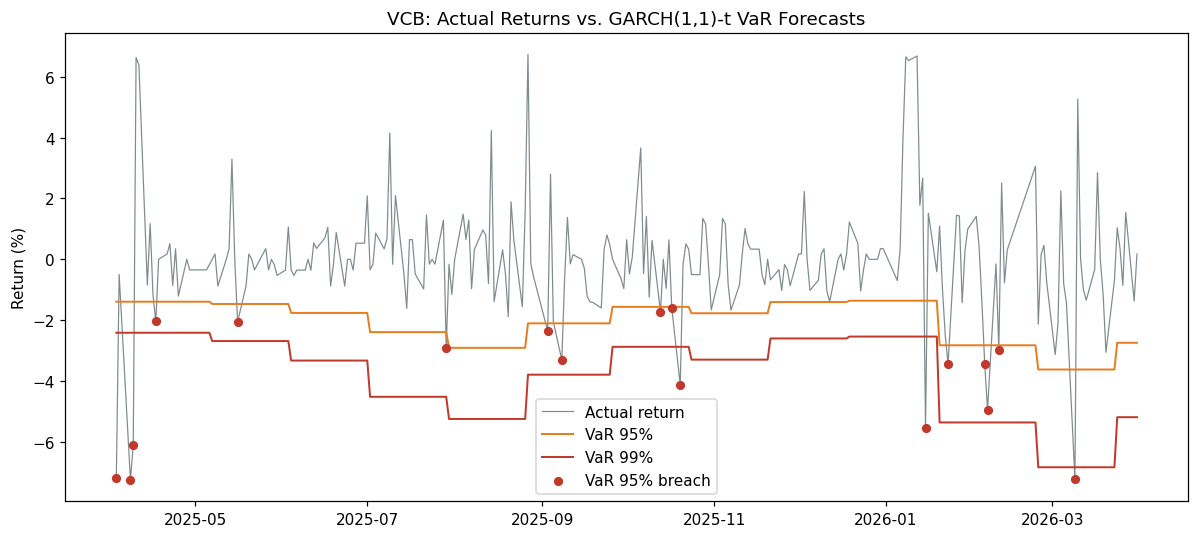

In [8]:
fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(backtest.index, backtest["actual_return"], color="#7F8C8D", linewidth=0.8, label="Actual return")
ax.plot(backtest.index, backtest["VaR_95"], color="#E67E22", linewidth=1.3, label="VaR 95%")
ax.plot(backtest.index, backtest["VaR_99"], color="#C0392B", linewidth=1.3, label="VaR 99%")

breaches_95 = backtest["actual_return"] < backtest["VaR_95"]
ax.scatter(backtest.index[breaches_95], backtest["actual_return"][breaches_95],
           color="#C0392B", s=25, zorder=5, label="VaR 95% breach")

ax.set_title("VCB: Actual Returns vs. GARCH(1,1)-t VaR Forecasts")
ax.set_ylabel("Return (%)")
ax.legend()
plt.tight_layout(); plt.show()


## 5. Backtesting the VaR forecasts (Kupiec test)

A VaR model is only useful if its breach rate matches its stated confidence level. The
**Kupiec proportion-of-failures test** checks this formally: under the null hypothesis that
the model is correctly calibrated, the number of breaches should follow a binomial
distribution with probability equal to $\alpha$.


In [9]:
for label, alpha in [("VaR_95", 0.05), ("VaR_99", 0.01)]:
    x, n, lr, p = kupiec_test(backtest["actual_return"], backtest[label], alpha)
    verdict = "well-calibrated (cannot reject)" if p >= 0.05 else "MISCALIBRATED (reject)"
    print(f"{label}: {x}/{n} breaches ({x/n:.2%} vs. expected {alpha:.2%})  "
          f"Kupiec LR={lr:.3f}, p={p:.4f}  -> {verdict}")


VaR_95: 17/246 breaches (6.91% vs. expected 5.00%)  Kupiec LR=1.698, p=0.1925  -> well-calibrated (cannot reject)
VaR_99: 6/246 breaches (2.44% vs. expected 1.00%)  Kupiec LR=3.671, p=0.0554  -> well-calibrated (cannot reject)


## 6. Results & discussion

| Metric | VaR 95% | VaR 99% |
|---|---:|---:|
| Expected breach rate | 5.00% | 1.00% |
| Observed breach rate | 6.91% | 2.44% |
| Kupiec p-value | 0.19 | 0.06 |
| Verdict | Well-calibrated | Well-calibrated (borderline) |

Neither test rejects the null of correct calibration at the 5% significance level, though the
99% VaR is borderline (p = 0.055) -- with only 246 out-of-sample days and a 1% target, a single
extra breach can swing the test noticeably, so this is a sample-size caveat rather than a clear
failure.

**Why Student-t GARCH rather than normal-GARCH:** the earlier Jarque-Bera and ARCH-LM tests
established *both* that returns are non-normal *and* that volatility is time-varying. A
normal-GARCH model would fix the second problem but still understate how often extreme moves
happen, since it forces the standardized residuals back into a thin-tailed normal shape. Using
Student-t innovations (with $\nu$ estimated from the data, not assumed) lets the model capture
both effects simultaneously -- which is precisely why the fitted $\nu \approx 3.1$ is so low:
the data is telling the model it needs very fat tails to fit well.

**CVaR vs. VaR:** at both confidence levels, CVaR is more negative than VaR by design -- VaR
only says "returns are at least this bad {alpha}% of the time," while CVaR answers the more
decision-relevant question, "given that we're in that bad {alpha}% scenario, how bad is it *on
average*?" The gap between VaR_99 (-3.83%) and CVaR_99 (-5.70%) shows the tail is not just
present but genuinely severe once you're past the threshold -- a point VaR alone would miss.


## 7. Limitations

- **Single-stock analysis (Sections 1-6).** Modeling VCB in isolation doesn't tell us whether
  the approach generalizes -- Section 8 below extends this across the full 40-stock universe.
- **Fixed refit frequency.** Refitting every 20 days (for computational speed) means the model
  can lag a true volatility regime change by up to that many days; refitting daily would be more
  faithful but far slower to compute here.
- **Backtest sample size.** 246 out-of-sample days is a modest sample for a 1%-level VaR test in
  particular -- the Kupiec test's power to detect miscalibration at that tail is limited with
  this few expected breaches (only ~2-3 expected).
- **Parametric VaR assumes the fitted Student-t shape is stable.** A historical-simulation or
  filtered-historical-simulation VaR would relax this assumption and could be compared directly
  against the parametric estimates here as a robustness check.


## 8. Extension: does this generalize beyond VCB?

A model that only works on one stock isn't very useful. This section fits the same GARCH(1,1)-t
specification independently across **all 40 stocks** in the dataset, then runs the full
walk-forward VaR backtest on a diverse 6-stock basket spanning different sectors (banking, real
estate, steel, consumer staples, technology, energy) to see whether the calibration result found
for VCB actually holds up elsewhere.


In [10]:
from statsmodels.stats.diagnostic import het_arch as _het_arch_unused  # already imported above

tickers = [c for c in df.columns if c != "VNINDEX"]
records = []

for tkr in tickers:
    r = (np.log(df[tkr] / df[tkr].shift(1)).dropna()) * 100
    if len(r) < 200:
        continue
    try:
        fit = arch_model(r, vol="Garch", p=1, q=1, dist="t").fit(disp="off")
        records.append({
            "ticker": tkr,
            "kurtosis": r.kurtosis(),
            "persistence": fit.params["alpha[1]"] + fit.params["beta[1]"],
            "nu_tail": fit.params["nu"],
        })
    except Exception:
        continue

cross_section = pd.DataFrame(records).set_index("ticker").sort_values("nu_tail")
print(f"GARCH(1,1)-t converged for {len(cross_section)}/{len(tickers)} stocks")
print("\nFattest tails (lowest nu -- most extreme risk):")
print(cross_section.head(5))
print("\nThinnest tails (highest nu -- closest to normal):")
print(cross_section.tail(5))


GARCH(1,1)-t converged for 40/40 stocks

Fattest tails (lowest nu -- most extreme risk):
        kurtosis  persistence  nu_tail
ticker                                
KDC      10.0388       1.0000   2.5458
TLH       2.4808       1.0000   2.7723
CNG       3.9262       1.0000   2.8716
NT2       3.1401       0.9714   3.0601
CTG       5.2747       0.7685   3.0712

Thinnest tails (highest nu -- closest to normal):
        kurtosis  persistence  nu_tail
ticker                                
VND       1.7317       0.9322   4.3358
NKG       1.5454       0.9479   4.4922
HSG       1.8389       0.9267   4.7302
CSV       1.1833       0.9401   4.7624
VOS       0.8541       0.9469   5.4541


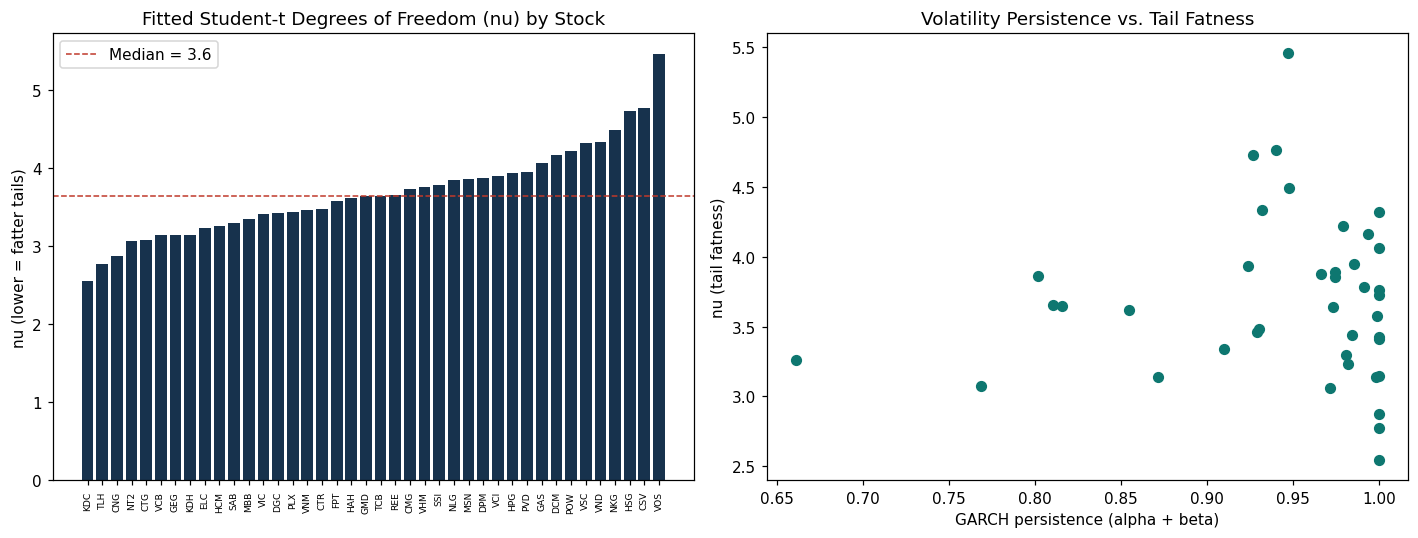

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].bar(cross_section.index, cross_section["nu_tail"], color="#17324D")
axes[0].axhline(cross_section["nu_tail"].median(), color="#C0392B", linestyle="--",
                linewidth=1, label=f"Median = {cross_section['nu_tail'].median():.1f}")
axes[0].set_title("Fitted Student-t Degrees of Freedom (nu) by Stock")
axes[0].set_ylabel("nu (lower = fatter tails)")
axes[0].tick_params(axis="x", rotation=90, labelsize=6)
axes[0].legend()

axes[1].scatter(cross_section["persistence"], cross_section["nu_tail"], color="#0E7770", s=40)
axes[1].set_xlabel("GARCH persistence (alpha + beta)")
axes[1].set_ylabel("nu (tail fatness)")
axes[1].set_title("Volatility Persistence vs. Tail Fatness")

plt.tight_layout(); plt.show()


There is substantial cross-sectional variation: `nu` ranges from ~2.5 (KDC -- extremely fat
tails) to ~5.5 (VOS -- close to normal), and persistence ranges from ~0.66 to a numerically
saturated 1.0 for several names (IGARCH-like behavior, common with volatile small/mid caps in
a short sample). No single "typical VN stock" risk profile exists here -- which is itself a
useful finding for anyone tempted to apply one GARCH configuration uniformly across a universe.

### Walk-forward VaR backtest across a diverse 6-stock basket

To see whether VCB's good calibration result generalizes, the same walk-forward VaR backtest
from Section 4 is repeated on a 6-stock basket spanning different sectors: **VCB** (banking),
**VIC** (real estate), **HPG** (steel), **VNM** (consumer staples), **FPT** (technology), and
**GAS** (energy).


In [12]:
def kupiec_test_multi(actual, var, alpha):
    breaches = (actual < var).astype(int)
    n, x = len(breaches), breaches.sum()
    pi_hat = x / n
    if pi_hat in (0, 1):
        return x, n, np.nan
    lr = -2 * (np.log((1 - alpha) ** (n - x) * alpha ** x)
               - np.log((1 - pi_hat) ** (n - x) * pi_hat ** x))
    return x, n, 1 - stats.chi2.cdf(lr, df=1)


def backtest_one_stock(log_ret, window=500, refit_every=20, alpha_levels=(0.05, 0.01)):
    var_out = {a: [] for a in alpha_levels}
    actual_out, dates_out = [], []
    fitted = None
    for t in range(window, len(log_ret)):
        if (t - window) % refit_every == 0 or fitted is None:
            fitted = arch_model(log_ret.iloc[t-window:t], vol="Garch", p=1, q=1,
                                 dist="t").fit(disp="off")
        fc = fitted.forecast(horizon=1, reindex=False)
        sigma = np.sqrt(fc.variance.values[-1, 0])
        mu, nu = fitted.params["mu"], fitted.params["nu"]
        scale = np.sqrt((nu - 2) / nu)
        for a in alpha_levels:
            var_out[a].append(mu + sigma * stats.t.ppf(a, df=nu) * scale)
        actual_out.append(log_ret.iloc[t])
        dates_out.append(log_ret.index[t])
    cols = {"actual": actual_out}
    for a in alpha_levels:
        cols[f"VaR_{int((1-a)*100)}"] = var_out[a]
    return pd.DataFrame(cols, index=pd.DatetimeIndex(dates_out))


basket = ["VCB", "VIC", "HPG", "VNM", "FPT", "GAS"]
summary_rows = []
for tkr in basket:
    r = (np.log(df[tkr] / df[tkr].shift(1)).dropna()) * 100
    bt = backtest_one_stock(r)
    x95, n95, p95 = kupiec_test_multi(bt["actual"], bt["VaR_95"], 0.05)
    x99, n99, p99 = kupiec_test_multi(bt["actual"], bt["VaR_99"], 0.01)
    summary_rows.append({"ticker": tkr, "breach_95": x95, "rate_95": x95/n95, "kupiec_p_95": p95,
                          "breach_99": x99, "rate_99": x99/n99, "kupiec_p_99": p99})

basket_summary = pd.DataFrame(summary_rows).set_index("ticker")
basket_summary


,breach_95,rate_95,kupiec_p_95,breach_99,rate_99,kupiec_p_99
ticker,,,,,,
VCB,17,0.0691,1.9254e-01,6,0.0244,0.0554
VIC,24,0.0976,2.3147e-03,7,0.0285,0.0175
HPG,13,0.0528,8.3915e-01,6,0.0244,0.0554
VNM,23,0.0935,4.9744e-03,7,0.0285,0.0175
FPT,17,0.0691,1.9254e-01,5,0.0203,0.1533
GAS,29,0.1179,2.7703e-05,5,0.0203,0.1533


**This is the more important result of the notebook.** VCB's well-calibrated VaR from Section 5
does **not** generalize uniformly:

| Ticker | Sector | VaR 95% calibrated? (p) | VaR 99% calibrated? (p) |
|---|---|---|---|
| HPG | Steel | Yes (0.84) | Borderline (0.06) |
| FPT | Technology | Yes (0.19) | Yes (0.15) |
| VCB | Banking | Yes (0.19) | Borderline (0.06) |
| VIC | Real Estate | **No (0.002)** | **No (0.02)** |
| VNM | Consumer Staples | **No (0.01)** | **No (0.02)** |
| GAS | Energy | **No (0.0002)** | Yes (0.15) |

Half the basket fails the 95% Kupiec test outright. This matters for how the earlier VCB result
should be read: it is evidence the *methodology* is sound and can produce well-calibrated risk
forecasts, not evidence that Student-t GARCH(1,1) with these exact settings is automatically
reliable for any VN stock. A production risk system built this way would need per-asset (or at
least per-sector) validation, not a single backtest assumed to generalize -- exactly the kind of
honest limitation that matters more than the headline VCB result alone.
